In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
import numpy as np
import torch
from datasets import Dataset
from setfit import SetFitModel
from setfit import SetFitTrainer

import re
import time
import requests
import trafilatura
from datetime import datetime, timedelta
from collections import defaultdict
import matplotlib.pyplot as plt


In [6]:


df = pd.read_csv("Test_Data.csv",index_col=False)
df["label"] = df["label"].astype(str).str.strip().str.lower()

#split model into train and test and cv - stratified 

train_df, temp_df = train_test_split(
    df, test_size=0.3, stratify=df["label"], random_state=42
)

val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df["label"], random_state=42
)

#encode labels

label2id = {"down": 0, "neutral": 1, "up": 2}
id2label = {v: k for k, v in label2id.items()}

for df_part in [train_df, val_df, test_df]:
    df_part["label"] = df_part["label"].map(label2id)

#convert to hugging face datasets


train_ds = Dataset.from_pandas(train_df[["text", "label"]])
val_ds = Dataset.from_pandas(val_df[["text", "label"]])
test_ds = Dataset.from_pandas(test_df[["text", "label"]])

#load Setfit

model = SetFitModel.from_pretrained("sentence-transformers/all-MiniLM-L6-v2")

#Train Setfit


trainer = SetFitTrainer(
    model=model,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    metric="f1",
    batch_size=16,
    num_iterations=20,   # how many contrastive steps
    num_epochs=1         # classifier training
)

trainer.train()


#eval model

preds = trainer.model(test_ds["text"])
true = test_ds["label"]

print("Accuracy:", accuracy_score(true, preds))
print("Macro F1:", f1_score(true, preds, average="macro"))



model_head.pkl not found on HuggingFace Hub, initialising classification head with random weights. You should TRAIN this model on a downstream task to use it for predictions and inference.
C:\Users\joven\AppData\Local\Temp\ipykernel_64160\1606272256.py:36: DeprecationWarning: `SetFitTrainer` has been deprecated and will be removed in v2.0.0 of SetFit. Please use `Trainer` instead.
  trainer = SetFitTrainer(


Map:   0%|          | 0/105 [00:00<?, ? examples/s]

***** Running training *****
  Num unique pairs = 4200
  Batch size = 16
  Num epochs = 1
c:\Users\joven\miniconda3\envs\setfit\lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
1,0.324900
50,0.231200
100,0.156800
150,0.080800
200,0.034000
250,0.021000


Accuracy: 0.782608695652174
Macro F1: 0.7805555555555556


In [7]:

FINANCE_KEYWORDS = {
    "inflation", "cpi", "core inflation", "price pressures", "prices",
    "interest rate", "interest rates", "rate hike", "rate cut",
    "bank of england", "boe", "federal reserve", "fed", "ecb",
    "monetary policy", "tightening", "easing", "hawkish", "dovish",
    "wages", "labour market", "labor market", "consumer prices", "central bank"
}

SENTENCE_KEYWORDS = {
    "inflation", "cpi", "core inflation", "interest rate", "interest rates",
    "rate hike", "rate cut", "bank of england", "boe", "federal reserve", "fed",
    "ecb", "central bank", "monetary policy", "tightening", "easing",
    "hawkish", "dovish", "wages", "prices", "consumer prices",
    "sticky inflation", "services inflation", "disinflation"
}

FORWARD_LOOKING_KEYWORDS = {
    "expect", "expected", "expects", "forecast", "forecasts", "projected",
    "outlook", "likely", "unlikely", "could", "may", "might", "should",
    "anticipated", "anticipate", "signals", "signalled", "guidance"
}


def weighted_sentiment(probs,entropy):

    """
    probs: array of shape (n_sentences, 3)
        columns = [p_up, p_neutral, p_down]
    """

    #extract probs
    p_up = probs[:, 2]
    #p_neutral = probs[:, 1]  --- IGNORE ---
    p_down = probs[:, 0]

    #calculate score
    scores = p_up - p_down

    #normalise entropy
    H = entropy
    H_norm = H / np.log(3.0)

    #calculate weighted score 
    weights = np.abs(p_up - p_down) * (1 - H_norm)
    total_weights = np.sum(weights)

    #calculate weighted probabilities  
    weightedp_up = np.average(p_up, weights=weights) if total_weights > 0 else None
    weightedp_down = np.average(p_down, weights=weights) if total_weights > 0 else None
    
    if total_weights == 0:
            return 0.0, 0.0, 0.0, 0.0

    return np.sum(weights * scores) / total_weights, total_weights, weightedp_up, weightedp_down

#build rates expectations index - Ei = P_up - P_down, 

def rates_expectations(model, texts, labels=("down","neutral","up")):

    """
    Computes rate expectation scores from text using a SetFit model.

    Returns:
        dict with:
        - scores: per-text (p_up - p_down)
        - mean_score: aggregate expectation
        - probs: full probability matrix
        - predictions: predicted labels
        - confidence: confidence of predicted class
    """

    # Get probabilities
    probs = model.predict_proba(texts)

    #convert to numpy array 
    if isinstance(probs, torch.Tensor):
        probs = probs.detach().cpu().numpy()
    else:
        probs = np.asarray(probs)

    # Predictions + confidence
    pred_idx = np.argmax(probs, axis=1)
    predictions = [labels[i] for i in pred_idx]
    confidence = probs[np.arange(len(probs)), pred_idx]
    entropy = -np.sum(probs* np.log(probs + 1e-10), axis=1)

    text_sentiment_score, total_weights, weightedp_up, weightedp_down = weighted_sentiment(probs, entropy)

    values_dict = {
        "weighted_score": text_sentiment_score,
        "total_weights": total_weights,
        "entropy": entropy,
        "probs": probs,
        "predictions": predictions,
        "confidence": confidence,
        "weightedp_up": weightedp_up,
        "weightedp_down": weightedp_down
     }


    return text_sentiment_score,total_weights, values_dict


def fetch_newsapi_articles(
    api_key,
    query,
    from_date=None,
    to_date=None,
    page_size=50,
    pages=1,
    language="en",
    search_in="title,description",
    domains=None,
    exclude_domains=None,
    sort_by="publishedAt"
):
    """
    Fetch article metadata from NewsAPI /v2/everything.
    This only gets metadata, not full article text.
    """
    url = "https://newsapi.org/v2/everything"
    all_articles = []

    for page in range(1, pages + 1):
        params = {
            "q": query,
            "language": language,
            "pageSize": page_size,
            "page": page,
            "sortBy": sort_by,
            "searchIn": search_in,
            "apiKey": api_key,
        }

        if from_date:
            params["from"] = from_date
        if to_date:
            params["to"] = to_date
        if domains:
            params["domains"] = ",".join(domains)
        if exclude_domains:
            params["excludeDomains"] = ",".join(exclude_domains)

        r = requests.get(url, params=params, timeout=20)
        r.raise_for_status()
        data = r.json()

        articles = data.get("articles", [])
        all_articles.extend(articles)

        if len(articles) < page_size:
            break

        time.sleep(0.5)

    return all_articles


def is_financial_or_inflation_related(title, description=""):
    text = f"{title or ''} {description or ''}".lower()
    return any(keyword in text for keyword in FINANCE_KEYWORDS)


def extract_article_text(url):
    """
    Download and extract main article text using Trafilatura.
    Returns None if extraction fails.
    """
    downloaded = trafilatura.fetch_url(url)
    if not downloaded:
        return None

    text = trafilatura.extract(
        downloaded,
        favor_precision=True,
        include_comments=False
    )
    return text


def split_into_sentences(text):
    if not text:
        return []
    sentences = re.split(r'(?<=[.!?])\s+', text.strip())
    return [s.strip() for s in sentences if s.strip()]


def sentence_score(sentence, title=""):
    """
    Score a sentence for relevance.
    Higher score = more likely useful for inflation / policy sentiment analysis.
    """
    s_lower = sentence.lower()
    title_lower = (title or "").lower()

    # basic keyword hits
    keyword_score = sum(kw in s_lower for kw in SENTENCE_KEYWORDS)

    # forward-looking language is often more useful for market sentiment
    forward_score = sum(kw in s_lower for kw in FORWARD_LOOKING_KEYWORDS)

    # overlap with title words
    title_words = set(re.findall(r"\b[a-z]{4,}\b", title_lower))
    sent_words = set(re.findall(r"\b[a-z]{4,}\b", s_lower))
    overlap_score = len(title_words & sent_words)

    # prefer medium-length sentences over tiny useless fragments
    word_count = len(sentence.split())
    if 8 <= word_count <= 40:
        length_score = 2
    elif 5 <= word_count <= 60:
        length_score = 1
    else:
        length_score = 0

    return (
        3 * keyword_score
        + 2 * forward_score
        + overlap_score
        + length_score
    )


def extract_key_sentences(text, title="", max_sentences=5, min_score=2):
    """
    Extract top-N relevant sentences from article text.
    """
    sentences = split_into_sentences(text)
    scored = []

    for i, s in enumerate(sentences):
        score = sentence_score(s, title=title)

        # slight preference for earlier sentences because journalists
        # keep pretending the important bit belongs near the top
        position_bonus = max(0, 2 - i * 0.1)
        total_score = score + position_bonus

        if total_score >= min_score:
            scored.append((total_score, s))

    scored.sort(key=lambda x: x[0], reverse=True)

    chosen = []
    seen = set()
    for _, s in scored:
        if s not in seen:
            chosen.append(s)
            seen.add(s)
        if len(chosen) >= max_sentences:
            break

    return chosen


def parse_article_day(article):
    published = article.get("publishedAt")
    if not published:
        return None
    # publishedAt usually looks like 2026-04-03T12:34:56Z
    return published[:10]


def default_sentiment_function(text):
    """
    Placeholder.
    Replace this with your trained model function.
    Should return a scalar score, e.g.:
      negative = -1
      neutral  = 0
      positive = +1
    or a continuous score.
    """
    return 0.0


def inter_article_directional_entropy(P_up, P_down, weights):
    P_up = np.array(P_up)
    P_down = np.array(P_down)
    weights = np.array(weights)

    total_weight = np.sum(weights)
    if total_weight == 0:
        return 0.0

    P_up_bar = np.sum(weights * P_up) / total_weight
    P_down_bar = np.sum(weights * P_down) / total_weight

    directional_mass = P_up_bar + P_down_bar
    if directional_mass <= 0:
        return 0.0

    p_up_dir = P_up_bar / directional_mass
    p_down_dir = P_down_bar / directional_mass

    probs = np.array([p_up_dir, p_down_dir])
    probs = np.clip(probs, 1e-12, 1.0)

    H = -np.sum(probs * np.log(probs))
    H_norm = H / np.log(2.0)

    return H_norm


def inter_article_entropy(P_up, P_down, weights):
    P_up = np.array(P_up)
    P_down = np.array(P_down)
    weights = np.array(weights)

    P_neutral = 1 - (P_up + P_down)

    total_weight = np.sum(weights)

    if total_weight == 0:
        return 0.0

    # weighted average probabilities
    P_up_bar = np.sum(weights * P_up) / total_weight
    P_down_bar = np.sum(weights * P_down) / total_weight
    P_neutral_bar = np.sum(weights * P_neutral) / total_weight

    probs = np.array([P_up_bar, P_neutral_bar, P_down_bar])
    probs = np.clip(probs, 1e-12, 1.0)

    H = -np.sum(probs * np.log(probs))
    H_norm = H / np.log(3.0)

    return H_norm


def weighted_variance(scores, weights):
    scores = np.array(scores)
    weights = np.array(weights)

    total_weight = np.sum(weights)

    if total_weight == 0:
        return 0.0

    mean = np.sum(weights * scores) / total_weight
    var = np.sum(weights * (scores - mean)**2) / total_weight

    return var


def build_daily_news_results(
    api_key,
    query,
    start_date,
    end_date,
    sentiment_fn=None,
    max_pages_per_day=1,
    page_size=50,
    max_sentences_per_article=7,
    domains=None,
    exclude_domains=None
):
    """
    Build results[day] dictionary:
      results[day]["articles"] -> list of processed article dicts
      results[day]["daily_sentiment_mean"] -> average sentiment of article snippets
      results[day]["n_articles"] -> number of usable articles
    """
    if sentiment_fn is None:
        sentiment_fn = default_sentiment_function

    results = defaultdict(lambda: {
        "articles": [],
        "daily_sentiment_score": None,
        "weighted_daily_sentiment_score": None,
        "n_articles": 0,
        "inter_article_entropy": None,
        "inter_article_directional_entropy": None,
        "weighted_variance": None
    })

    start_dt = datetime.strptime(start_date, "%Y-%m-%d")
    end_dt = datetime.strptime(end_date, "%Y-%m-%d")

    current = start_dt
    while current <= end_dt:
        day_str = current.strftime("%Y-%m-%d")
        next_day_str = (current + timedelta(days=1)).strftime("%Y-%m-%d")

        # Fetch one day at a time to control quota and keep clean time series
        raw_articles = fetch_newsapi_articles(
            api_key=api_key,
            query=query,
            from_date=day_str,
            to_date=next_day_str,
            page_size=page_size,
            pages=max_pages_per_day,
            language="en",
            search_in="title,description",
            domains=domains,
            exclude_domains=exclude_domains,
            sort_by="publishedAt"
        )

        # Cheap metadata filter before full-text extraction
        filtered_articles = []
        seen_urls = set()

        for article in raw_articles:
            url = article.get("url")
            if not url or url in seen_urls:
                continue
            seen_urls.add(url)

            title = article.get("title", "")
            desc = article.get("description", "")

            if is_financial_or_inflation_related(title, desc):
                filtered_articles.append(article)


        #create empty arrays to hold article sentiment scores, article weighted probabilities and weights for aggregation later
        article_sentiment_scores = np.array([])
        article_weights = np.array([])
        article_P_up = np.array([])
        article_P_down = np.array([])

        #l
        for article in filtered_articles:
            title = article.get("title", "")
            url = article.get("url", "")
            source = (article.get("source") or {}).get("name")
            published_at = article.get("publishedAt")

            text = extract_article_text(url)
            if not text:
                continue

            key_sentences = extract_key_sentences(
                text,
                title=title,
                max_sentences=max_sentences_per_article
            )

            if not key_sentences:
                continue

            #sentiment score per article and article weight score based on confidence and entropy of sentence predictions
            article_sentiment_score, article_weight, dict_val = sentiment_fn(model,key_sentences)

            #add article scores, weights and probabilities to arrays for later aggregation
            article_sentiment_scores = np.append(article_sentiment_scores, article_sentiment_score)
            article_weights = np.append(article_weights, article_weight)
            article_P_up = np.append(article_P_up, dict_val.get("weightedp_up", 0))
            article_P_down = np.append(article_P_down, dict_val.get("weightedp_down", 0))


            #add key articles information to results dict for the day 
            results[day_str]["articles"].append({
                "title": title,
                "url": url,
                "source": source,
                "publishedAt": published_at,
                "key_sentences": key_sentences,
                "sentiment_score": article_sentiment_score,
                "article_weight": article_weight
            })


        #calculate amount of articles for the day 
        results[day_str]["n_articles"] = len(results[day_str]["articles"])



        #calculate weighted daily sentiment scores using article sentiment scores and weights
        weighted_daily_sentiment_score = np.average(article_sentiment_scores, weights=article_weights) if article_weights.size > 0 else None
        
        if article_sentiment_scores.size > 0:
            results[day_str]["daily_sentiment_score"] = np.mean(article_sentiment_scores)

        results[day_str]["weighted_daily_sentiment_score"] = weighted_daily_sentiment_score


        #ENTROPY CALCULATION
        #calculate inter-article entropy as a measure of disagreement among article sentiments

        if article_P_up.size > 0 and article_P_down.size > 0 and article_weights.size > 0:
            inter_article_ent = inter_article_entropy(article_P_up, article_P_down, article_weights)
            results[day_str]["inter_article_entropy"] = inter_article_ent

        # calculate inter-article directional entropy

            inter_article_dir_ent = inter_article_directional_entropy(article_P_up, article_P_down, article_weights)
            results[day_str]["inter_article_directional_entropy"] = inter_article_dir_ent
            
        #calculate weighted variance of article sentiment scores as another measure of disagreement         
        if article_sentiment_scores.size > 0 and article_weights.size > 0:
            weighted_var = weighted_variance(article_sentiment_scores, article_weights)
            results[day_str]["weighted_variance"] = weighted_var

        current += timedelta(days=1)

    return dict(results)

In [23]:
NEWSAPI_KEY = "0cdaaa7d6b5c49d69867ddafa4fb4229"
#NEWSAPI_KEY = "d229ea6ffc58476f91acb9c22dd9566f"

QUERY = (
    '("inflation" OR "CPI" OR "core inflation" OR "interest rates" '
    'OR "rate hike" OR "rate cut" OR "monetary policy" '
    'OR "central bank" OR "Bank of England" OR "Federal Reserve" OR "ECB")'
)

TRUSTED_DOMAINS = [
    "reuters.com",
    "ft.com",
    "bloomberg.com",
    "wsj.com",
    "cnbc.com"
]

results = build_daily_news_results(
    api_key=NEWSAPI_KEY,
    query=QUERY,
    start_date="2026-03-7",
    end_date="2026-04-06",
    sentiment_fn=rates_expectations,
    max_pages_per_day=3,
    page_size=25,
    max_sentences_per_article=7,
    domains=TRUSTED_DOMAINS
)

In [24]:

results_df = pd.DataFrame(results)

# add 6-day rolling average of daily sentiment score and weighted daily sentiment score
results_df.loc["daily_sentiment_score_6d_avg"] = (
    results_df.loc["daily_sentiment_score"].rolling(window=6, min_periods=1).mean()
)

results_df.loc["weighted_daily_sentiment_score_6d_avg"] = (
    results_df.loc["weighted_daily_sentiment_score"].rolling(window=6, min_periods=1).mean()
)
results_df.head(10)



,2026-03-07,2026-03-08,2026-03-09,2026-03-10,2026-03-11,2026-03-12,2026-03-13,2026-03-14,2026-03-15,2026-03-16,...,2026-03-28,2026-03-29,2026-03-30,2026-03-31,2026-04-01,2026-04-02,2026-04-03,2026-04-04,2026-04-05,2026-04-06
articles,[{'title': 'Global week ahead: Diplomacy in ru...,[{'title': 'Fears of 1970s-style stagflation a...,[{'title': 'Thom Tillis refuses to budge on bl...,[{'title': 'Social Security 2027 cost-of-livin...,[{'title': 'Markets hopes for Fed interest rat...,[{'title': 'Federal Reserve investigation: U.S...,[{'title': 'Federal Reserve investigation: U.S...,[{'title': 'Global week ahead: Price pressure ...,"[{'title': 'Oil continues to rise, the Federal...",[{'title': 'The Fed issues its latest interest...,...,[{'title': 'Global week ahead: Why emergency G...,[{'title': 'Powell sees inflation outlook in c...,"[{'title': 'Wall Street's rough month, Powell'...",[{'title': 'Prices may rise more this year tha...,[{'title': 'Cramer’s week ahead: Two key econo...,[{'title': 'Cramer’s week ahead: Two key econo...,[],[],[{'title': 'Jim Cramer says potential stock ma...,[{'title': 'Treasury yields hold steady as tra...
daily_sentiment_score,0.68688,0.041137,-0.243056,0.244724,0.26507,-0.127562,-0.172651,-0.186286,0.106727,0.347563,...,0.479451,-0.046171,0.097991,0.391424,0.362698,0.19418,None,None,0.36565,0.205081
weighted_daily_sentiment_score,0.68688,-0.106452,-0.263437,0.289555,0.295565,-0.104202,-0.127198,-0.186286,0.098731,0.489816,...,0.607066,-0.175559,0.169747,0.409772,0.355461,0.19418,None,None,0.27281,0.205081
n_articles,1,5,7,7,9,7,2,1,2,3,...,2,4,6,4,2,1,0,0,2,1
inter_article_entropy,0.641501,0.890066,0.842851,0.845524,0.85059,0.914911,0.988686,0.915842,0.915896,0.792609,...,0.725402,0.975488,0.927762,0.829879,0.871248,0.93649,None,None,0.854913,0.849663
inter_article_directional_entropy,0.368419,0.989276,0.93561,0.920347,0.915702,0.989141,0.974708,0.963748,0.990244,0.7375,...,0.518498,0.955905,0.969128,0.8238,0.861262,0.957439,None,None,0.928807,0.961735
weighted_variance,0.0,0.337513,0.18122,0.279673,0.263249,0.155906,0.024585,0.0,0.085792,0.10267,...,0.031063,0.088614,0.171258,0.075546,0.028346,0.0,None,None,0.017163,0.0
daily_sentiment_score_6d_avg,0.68688,0.364009,0.161654,0.182421,0.198951,0.144532,0.001277,-0.036627,0.02167,0.03881,...,0.246027,0.228578,0.196962,0.234243,0.27917,0.246595,0.200024,0.261573,0.328488,0.281902
weighted_daily_sentiment_score_6d_avg,0.68688,0.290214,0.105663,0.151636,0.180422,0.132985,-0.002695,-0.016001,0.044361,0.077738,...,0.299961,0.259528,0.250021,0.281058,0.29774,0.260111,0.19072,0.28229,0.308056,0.256883


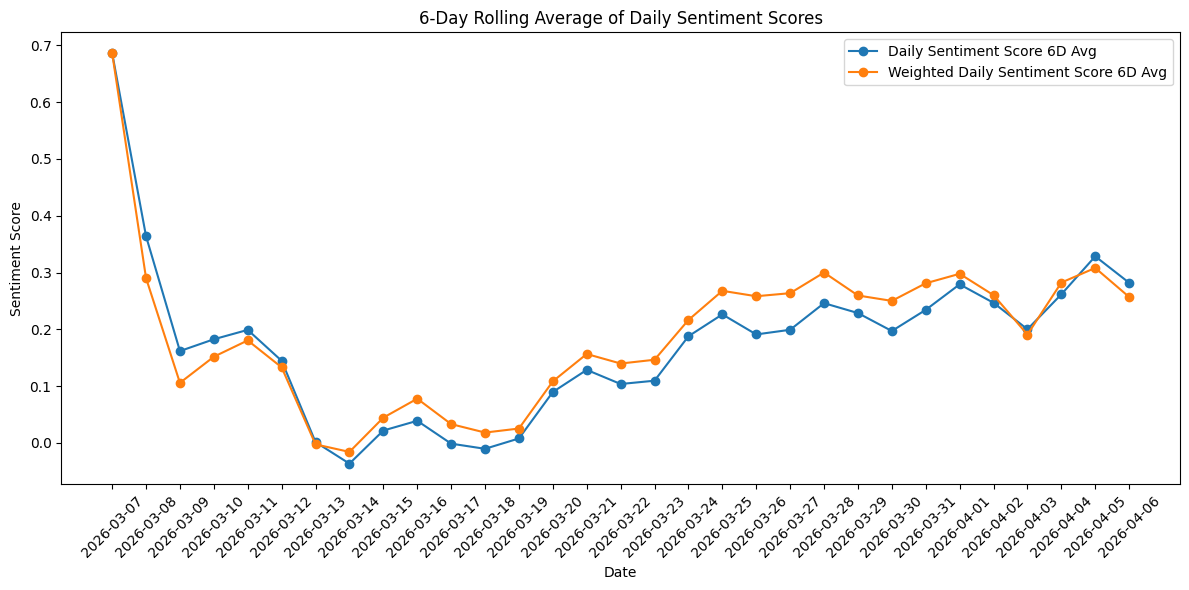

In [25]:
#plot 5d rolling average of daily sentiment score and weighted daily sentiment score

plt.figure(figsize=(12, 6))
plt.plot(results_df.columns, results_df.loc["daily_sentiment_score_6d_avg"],
            label="Daily Sentiment Score 6D Avg", marker='o')
plt.plot(results_df.columns, results_df.loc["weighted_daily_sentiment_score_6d_avg"],
            label="Weighted Daily Sentiment Score 6D Avg", marker='o')
plt.xticks(rotation=45)
plt.xlabel("Date")
plt.ylabel("Sentiment Score")
plt.title("6-Day Rolling Average of Daily Sentiment Scores")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
#find historical datasets on kaggle and hugging-face

#extend analysis to dates before the war 